In [ ]:
# Tries to open a file and catches the exception if the file does not exist.
try:
    f = open('myfile.fa')
except OSError:
    print("File not found. Please check the file name and try again.")

The section below reads a FASTA file which looks like the following.

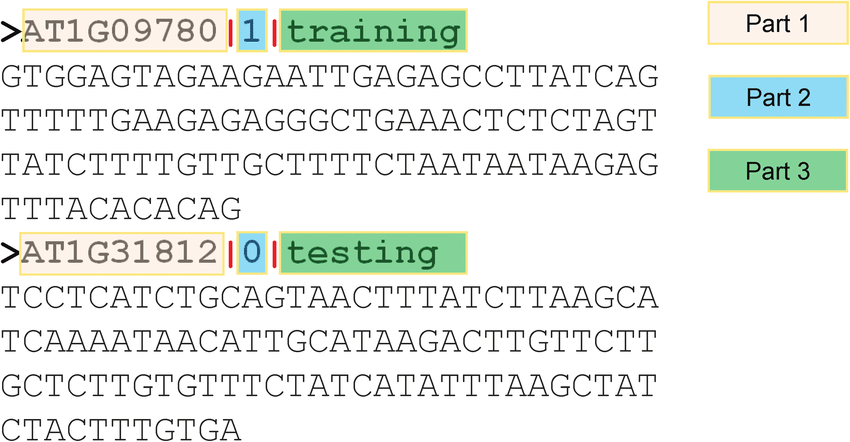

Cited from iLearn May, 2020 Uploaded by Song, Jiangning

The FASTA file is a text file that has gene sequences with labels that identify them.

In [ ]:
seqs = {}

for line in f:
    # Remove trailing whitespace from the line
    line = line.rstrip()

    # Creates a new entry in the dictionary if the line starts with '>', otherwise it appends the line to the current sequence.
    if line.startswith('>'):
        words = line.split()
        name = words[0][1:]
        seqs[name] = ''
    else:
        seqs[name] += line        

The section below demonstrates retrieving data from dictionaries in the context of FASTA files.

In [ ]:
for name, seq in seqs.items():
    print(name, seq)


One aspect of running python programs in this context is processing command line arguments. These modify how we run our programs.



In [ ]:
# Example of a script that takes a FASTA file as input
# >python processfasta.py myfile.fa

import sys
print(sys.argv)

# sys.argv is a list in Python
#['processfasta.py', 'myfile.fa']

In [ ]:
f.close()

In [2]:
pip install biopython

^C
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\ymaza\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.7 MB 3.9 MB/s eta 0:00:01
   ---------------------------------- ----- 2.4/2.7 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 5.4 MB/s  0:00:00
   ---------------------------------------- 0.0/12.5 MB ? eta -:--:--
   ----- ---------------------------------- 1.6/12.5 MB 7.3 MB/s eta 0:00:02
   -------- ------------------------------- 2.6/12.5 MB 6.2 MB/s eta 0:00:02
   ------------ --------------------------- 3.9/12.5 MB 5.9 MB/s eta 0:00:02
   ---------------- ----------------------- 5.2/12.5 MB 6.2 MB/s eta 0:00:02
   -------------------- ------------------- 6.3/12.5 MB 5.8 MB/s eta 0:00:02
   ------------------------- -------------- 7.9/12.5 MB 6.1 MB/s eta 0:00:01
   ------------------------

In [1]:
import Bio
print(Bio.__version__)

1.88


In [2]:
from Bio.Blast import NCBIWWW

In [ ]:
fasta_string = open("myseq.fa").read()
result_handle = NCBIWWW.qblast("blastn", "nt", fasta_string)

In [ ]:
from Bio.Blast import NCBIXML

In [ ]:
blast_record = NCBIXML.read(result_handle)

In [ ]:
len(blast_record.alignments)

In [ ]:
E_VALUE_THRESH = 0.04
# the following code iterates through the alignments and HSPs in the BLAST record, printing out information about each alignment that has an e-value below the specified threshold.
for alignment in blast_record.alignments:
    for hsp in alignment.hsps:
        if hsp.expect < E_VALUE_THRESH:
            print('****Alignment****')
            print('sequence:', alignment.title)
            print('length:', alignment.length)
            print('e value:', hsp.expect)
            print(hsp.query[0:75] + '...')
            print(hsp.match[0:75] + '...')
            print(hsp.sbjct[0:75] + '...')

Example Output

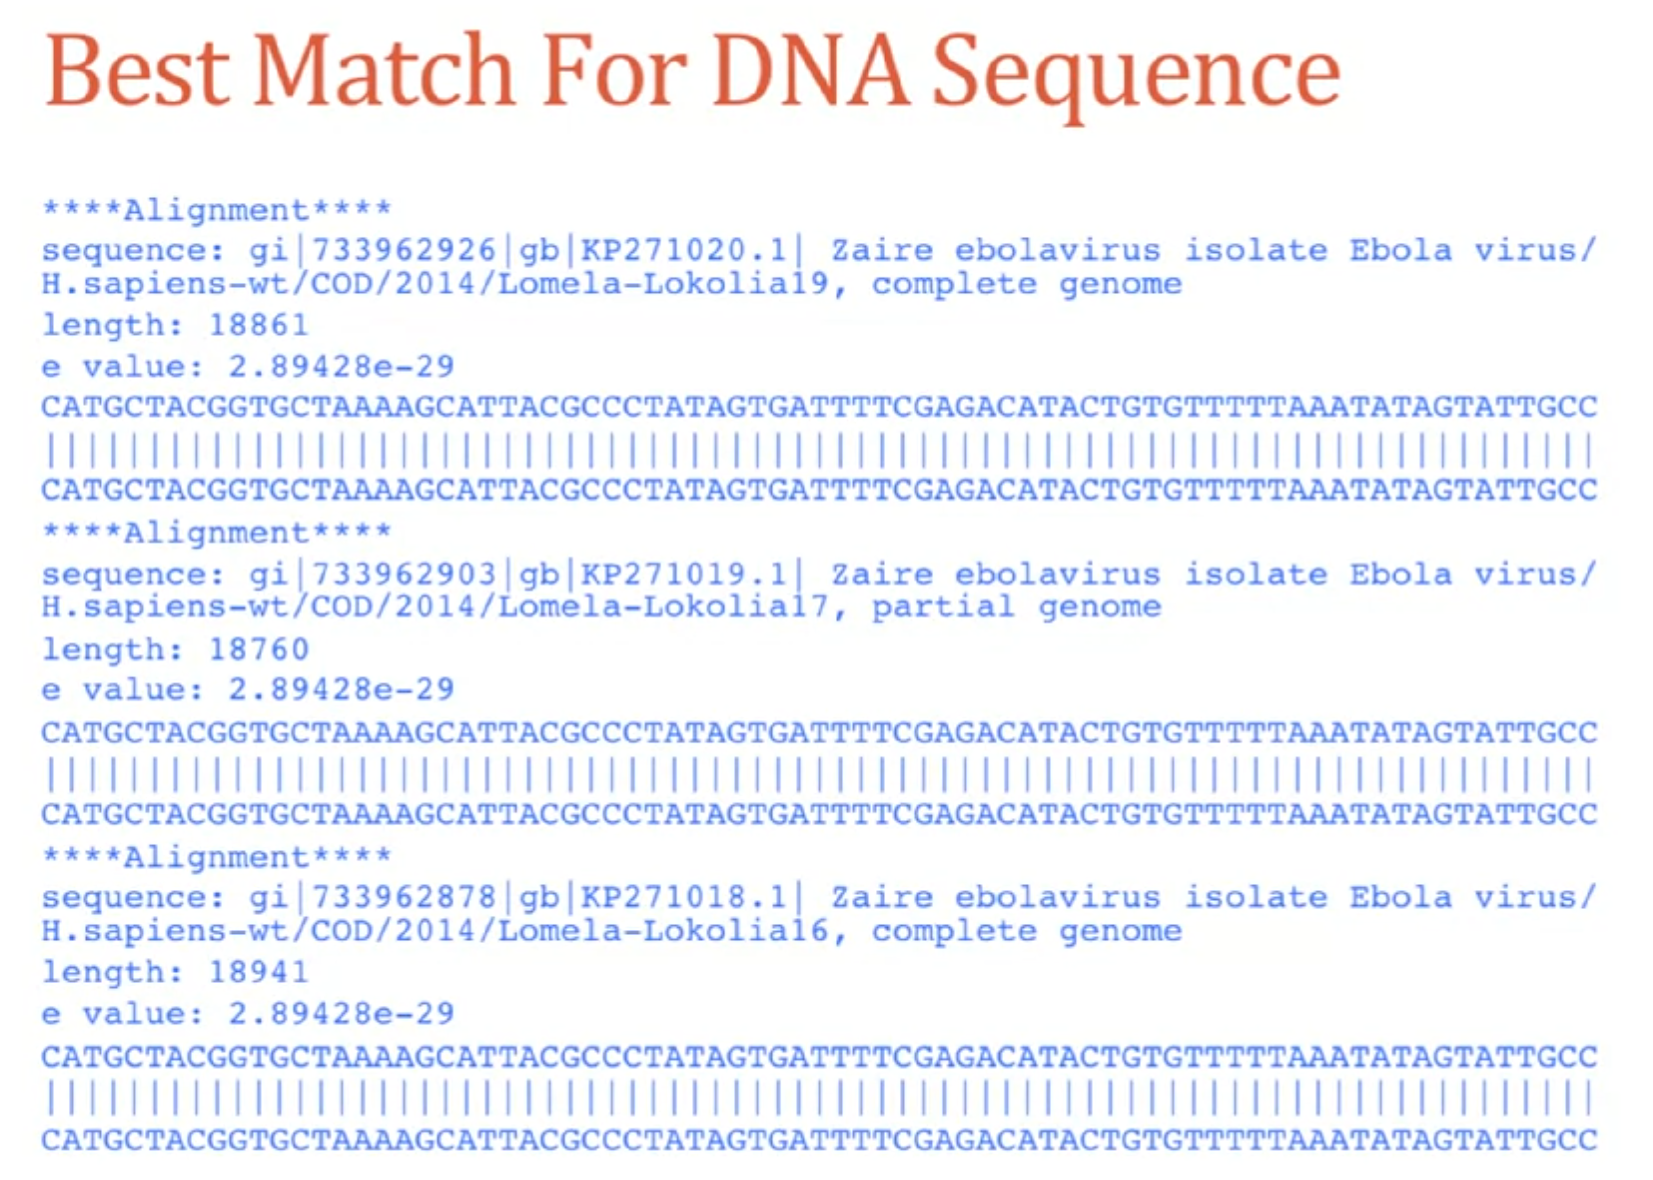
Cited from John Hopkin's Python for Genomic Data Science course on Coursera

Output shows patient has strains of ebola virus

In [ ]:
# Lecture 8 Quiz Question 3: Use Biopython to find out origin of DNA

'''
TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGACATCATACCAAAGTCGTAC
AATTAGGACCTCGATATGGTTTTATTCTGTTTATCGTATCGGAGGTTATGTTCTTTTTTGCTCTTTTTCGGGCTTCTTCTCATTCTTCTTTGGCAC
CTACGGTAGAG
'''

from Bio.Blast import NCBIWWW, NCBIXML

dna_seq = "TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGACATCATACCAAAGTCGTACAATTAGGACCTCGATATGGTTTTATTCTGTTTATCGTATCGGAGGTTATGTTCTTTTTTGCTCTTTTTCGGGCTTCTTCTCATTCTTCTTTGGCACCTACGGTAGAG"
result_handle2 = NCBIWWW.qblast("blastn", 'nt', dna_seq)

blast_record2 = NCBIXML.read(result_handle2)




TypeError: object of type 'Blast' has no len()

In [9]:
E_VAlUE_THRESHOLD2 = 0.01
for alignment in blast_record2.alignments:
    for hsp in alignment.hsps:
        if hsp.expect < E_VAlUE_THRESHOLD2:
            print('****Alignment****')
            print('sequence:', alignment.title)
            print('length:', alignment.length)
            print('e value:', hsp.expect)
            print(hsp.query[0:75] + '...')
            print(hsp.match[0:75] + '...')
            print(hsp.sbjct[0:75] + '...')

****Alignment****
sequence: gi|1783584753|gb|MN651324.1| Nicotiana tabacum strain zhongyan90 cytoplasmic male sterility(CMS) line cultivar MSzhongyan90 mitochondrion, complete genome
length: 530869
e value: 1.76069e-95
TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGAC...
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||...
TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGAC...
****Alignment****
sequence: gi|2324144687|gb|OK109657.1| Nicotiana tabacum mitochondrion, complete genome
length: 494317
e value: 1.76069e-95
TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGAC...
|||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||||...
TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGAC...
****Alignment****
sequence: gi|2566845327|gb|OR187866.1| Solanum melongena cultivar CMS line EP28A mitochondrion, complete genome
length: 594450
e value: 1.76069e-95

In [10]:
from Bio.Seq import Seq

help(Seq)

Help on class Seq in module Bio.Seq:

class Seq(_SeqAbstractBaseClass)
 |  Seq(
 |      data: str | bytes | bytearray | Bio.Seq._SeqAbstractBaseClass | Bio.Seq.SequenceDataAbstractBaseClass | dict | None,
 |      length: int | None = None
 |  )
 |
 |  Read-only sequence object (essentially a string with biological methods).
 |
 |  Like normal python strings, our basic sequence object is immutable.
 |  This prevents you from doing my_seq[5] = "A" for example, but does allow
 |  Seq objects to be used as dictionary keys.
 |
 |  The Seq object provides a number of string like methods (such as count,
 |  find, split and strip).
 |
 |  The Seq object also provides some biological methods, such as complement,
 |  reverse_complement, transcribe, back_transcribe and translate (which are
 |  not applicable to protein sequences).
 |
 |  Method resolution order:
 |      Seq
 |      _SeqAbstractBaseClass
 |      abc.ABC
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __hash__(self)
 | 

In [12]:
dna_seq2 = '''TGGGCCTCATATTTATCCTATATACCATGTTCGTATGGTGGCGCGATGTTCTACGTGAATCCACGTTCGAAGGACATCATACCAAAGTCGTACAATTAGGACCTCGATATGGTTTTATTCTGTTTATCGTATCGGAGGTTATGTTCTTTTTTGCTCTTTTTCGGGCTTCTTCTCATTCTTCTTTGGCACCTACGGTAGAG'''
coding_dna = Seq(dna_seq2)
aa_seq = coding_dna.translate()
print(aa_seq)


WASYLSYIPCSYGGAMFYVNPRSKDIIPKSYN*DLDMVLFCLSYRRLCSFLLFFGLLLILLWHLR*


C:\Users\ymaza\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\Bio\Seq.py:2874: BiopythonWarning: Partial codon, len(sequence) not a multiple of three. Explicitly trim the sequence or add trailing N before translation. This may become an error in future.
  warnings.warn(
